# Example: Estimating Single Index Model Parameters with Bootstrap Uncertainty

In this example, we load the frozen synthetic training dataset (20 years of [JumpHMM](https://github.com/varnerlab/JumpHMM.jl)-generated market data), estimate Single Index Model (SIM) parameters for a demonstration ticker, quantify parameter uncertainty via bootstrap resampling, and then estimate parameters for the full 424-ticker universe and save the results.

The Single Index Model earns its place in the pipeline for three reasons.

* __Workhorse factor model:__ Decomposes each asset's return into a market-driven component and a firm-specific residual, which is the empirically useful split for equity modeling.
* __Parameter reduction:__ Replaces the $N(N+1)/2$ free covariances of a full sample covariance with $N + 1$ parameters (one market volatility $\sigma_{m}$ plus one residual volatility $\sigma_{\varepsilon,i}$ per asset), which is what makes Markowitz-style optimization feasible with realistic data.
* __Downstream dependency:__ The parameters estimated here feed directly into every Session 1 notebook that builds a covariance matrix or a scenario.

That is why we run the estimation once and persist the output to disk.

> __Learning Objectives:__
>
> * __Estimate SIM parameters for a single asset:__ Regress asset returns on market returns via regularized ordinary least squares (OLS) to obtain alpha, beta, and residual volatility. Interpret the estimated parameters and evaluate the regression fit.
> * __Bootstrap uncertainty quantification:__ Resample residuals to build the empirical sampling distribution of alpha and beta. Compare bootstrap confidence intervals to theoretical standard errors.
> * __Estimate SIM parameters across the full ticker universe:__ Run SIM estimation and bootstrap for all tickers in the synthetic training dataset. Save the complete parameter set to disk for use in downstream sessions.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants


In [ ]:
# Demo and bootstrap configuration
Δt = 1.0 / 252.0
demo_ticker = "UPS"
N_BOOTSTRAP = 1_000
BOOTSTRAP_SEED = 42


Next, we'll load the 20-year synthetic training dataset using [the `MySyntheticTrainingDataSet()` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet) and extract market growth rates (scaled log returns) and the full ticker list. The notebook constants live in the `### Constants` subsection above; change `demo_ticker` there to explore different assets.

The code below loads the dataset, extracts the market returns, and prints a summary.


In [2]:
# --- Step 1: Load the frozen synthetic training dataset ---
training_data = MySyntheticTrainingDataSet();
dataset = training_data["dataset"];             # Dict of ticker DataFrames
all_tickers = training_data["tickers"];          # sorted vector of 424 ticker symbols
market_prices = training_data["market_prices"];  # market index price series
market_returns = training_data["market_returns"]; # market excess growth rates (length T_DAYS - 1)
T = length(market_returns);                       # number of daily return observations
# --- Step 3: Compute daily log growth rates for the demo ticker ---
demo_prices = dataset[demo_ticker][:, :close];
demo_returns = [(1.0/Δt) * log(demo_prices[t]/demo_prices[t-1]) for t ∈ 2:length(demo_prices)];

# --- Step 4: Print summary ---
println("Training data: $(T) daily returns, $(length(all_tickers)) tickers")
println("Demo ticker: $(demo_ticker)")
println("Market return observations: $(T)")
println("Demo ticker return observations: $(length(demo_returns))")

Training data: 5039 daily returns, 424 tickers
Demo ticker: UPS
Market return observations: 5039
Demo ticker return observations: 5039


### Implementation
We define a helper function used in Task 1 to visualize the SIM regression fit.

In [3]:
"""
    plot_sim_fit(ticker, est, actual_returns, market_rets) -> Plots.Plot

Generate a scatter plot of SIM-predicted vs. actual daily log growth rates for `ticker`.
Uses the point estimate `est::MySIMParameterEstimate` and the provided return vectors.
Returns a `Plots.Plot` object with predicted returns on the x-axis, actual returns on the y-axis,
and a dashed x = y reference line.
"""
function plot_sim_fit(ticker::String, est::MySIMParameterEstimate, 
        actual_returns::Vector{Float64}, market_rets::Vector{Float64})

    ŷ = est.α .+ est.β .* market_rets;  # SIM-predicted returns
    lims = (min(minimum(ŷ), minimum(actual_returns)), max(maximum(ŷ), maximum(actual_returns)));
    scatter(ŷ, actual_returns, alpha=0.3, ms=2, color=:navy, label="",
        xlabel="Predicted gᵢ", ylabel="Actual gᵢ",
        title="$(ticker) (R²=$(round(est.r², digits=3)), β=$(round(est.β, digits=2)))");
    plot!([lims...], [lims...], lw=2, ls=:dash, color=:red, label="x = y")
end;

___
## Task 1: Estimate SIM Parameters for a Single Ticker
In this task, we estimate the Single Index Model parameters $(\alpha_{i}, \beta_{i}, \sigma_{\varepsilon,i})$ for the demo ticker via regularized OLS regression.

> __Single Index Model__
>
> The Single Index Model decomposes each asset's growth rate into a market-driven component and a firm-specific component: $g_{i}(t) = \alpha_{i} + \beta_{i}\,g_{\mathrm{mkt}}(t) + \varepsilon_{i}(t)$, where
>
> * $\alpha_{i}$ is **Jensen's alpha**: the expected excess growth rate not explained by market exposure. A positive $\alpha$ means the asset outperforms what its market beta alone would predict.
> * $\beta_{i}$ is the **market beta**: the asset's sensitivity to the market factor. $\beta > 1$ amplifies market moves, $\beta < 1$ dampens them, and $\beta \approx 0$ means the asset is largely uncorrelated with the market.
> * $\sigma_{\varepsilon,i}$ is the **residual volatility**: the standard deviation of the firm-specific error term $\varepsilon_{i}(t)$ (idiosyncratic risk not captured by the single market factor).
> * $R^{2}$ is the **coefficient of determination**: the fraction of the asset's total variance explained by the market factor. $R^{2} \to 1$ means the asset is almost entirely a market play; $R^{2} \to 0$ means it trades on its own fundamentals.
>
> The parameters $(\alpha_{i}, \beta_{i})$ are estimated by ridge-regularized ordinary least squares: $\hat{\theta} = (X^{\top}X + \delta I)^{-1} X^{\top} y$ where $X = [\mathbf{1}\ \ g_{\mathrm{mkt}}]$ and $y = g_{i}$. Setting $\delta = 0$ recovers plain OLS.

With the model defined, we turn to estimation.

> __What are we going to do?__
>
> We regress the demo ticker's daily growth rates on market returns using [the `estimate_sim(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.estimate_sim). The result is [the `MySIMParameterEstimate` type](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMParameterEstimate) containing Jensen's alpha, market beta, residual volatility, and the regression $R^{2}$.

The code below calls [the `estimate_sim(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.estimate_sim) and stores the result in `demo_estimate::MySIMParameterEstimate` for use in subsequent cells.

In [4]:
demo_estimate = let

    # --- Step 1: Estimate SIM parameters for the demo ticker ---
    est = estimate_sim(market_returns, demo_returns, demo_ticker; δ=0.0);

    # --- Step 2: Build a parameter summary DataFrame ---
    # α and σ_ε come out of estimate_sim in annualized growth-rate units (1/year).
    # "Growth-rate %/yr" is the direct growth-rate convention (·100).
    # "Finance vol %/yr" applies the practitioner-standard scaling for σ_ε,
    # sqrt(252)·std(daily log return) = σ_ε / sqrt(252), which matches the
    # "annualized volatility" number a finance practitioner would quote.
    df = DataFrame(
        "Parameter" => ["α (Jensen's alpha)", "β (market beta)", "σ_ε (residual vol)", "R²"],
        "Raw value" => [
            round(est.α, digits=6),
            round(est.β, digits=4),
            round(est.σ_ε, digits=4),
            round(est.r², digits=4)
        ],
        "Growth-rate %/yr" => [
            "$(round(est.α * 100, digits=2))%",
            "",
            "$(round(est.σ_ε * 100, digits=1))%",
            ""
        ],
        "Finance vol %/yr" => [
            "",
            "",
            "$(round(est.σ_ε / sqrt(252) * 100, digits=2))%",
            ""
        ]
    );

    # --- Step 3: Display ---
    println("SIM Parameter Estimates for $(demo_ticker):")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    est
end;

SIM Parameter Estimates for UPS:
 -------------------- ----------- ------------------ ------------------
           Parameter   Raw value   Growth-rate %/yr   Finance vol %/yr 
              String     Float64             String             String 
 -------------------- ----------- ------------------ ------------------
  α (Jensen's alpha)   -0.074371             -7.44%
     β (market beta)      0.8672
  σ_ε (residual vol)      3.1425             314.2%              19.8%
                  R²      0.4263
 -------------------- ----------- ------------------ ------------------


> __How to read the table__
>
> * The **market beta** $\beta$ tells us whether the ticker amplifies ($\beta > 1$) or dampens ($\beta < 1$) market moves. Values far from 1 indicate strong factor tilts; $\beta$ near 0 means the ticker is largely uncorrelated with the market.
> * The **coefficient of determination** $R^{2}$ measures how much of the ticker's variance the single market factor explains. A high $R^{2}$ means the ticker is well-modeled by SIM alone; a low $R^{2}$ means firm-specific risk dominates and the residual term $\varepsilon_{i}$ carries most of the behavior.
> * The **residual volatility** $\sigma_{\varepsilon}$ in annualized units gauges the size of that firm-specific risk. Combined with $\beta$, it tells us whether the ticker's volatility is primarily market-driven or idiosyncratic.

The scatter plot below shows SIM-predicted versus actual daily growth rates for the demo ticker. The dashed $x = y$ line is where a perfect SIM prediction would lie; the spread of points around that line is the empirical residual $\varepsilon_{i}$, and its tightness is the visual analog of $R^{2}$.

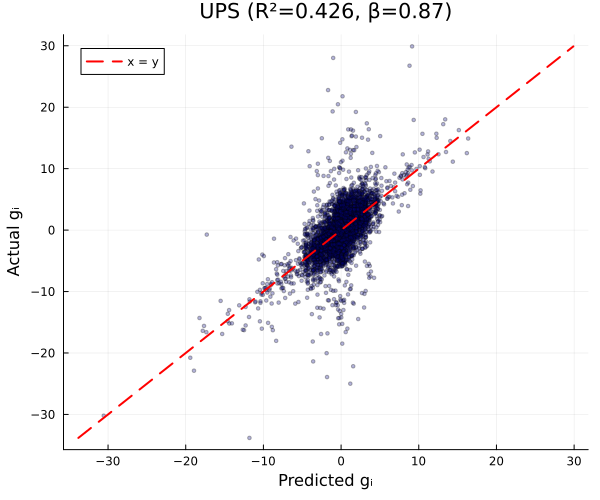

In [5]:
# --- Scatter plot: SIM-predicted vs actual returns ---
plot_sim_fit(demo_ticker, demo_estimate, demo_returns, market_returns) |>
    p -> plot!(p, size=(600, 500))

___
## Task 2: Bootstrap Uncertainty Quantification
In this task, we quantify the uncertainty in our SIM parameter estimates by bootstrap resampling.

A single point estimate is incomplete. If the true $\beta$ could plausibly sit anywhere in a wide interval around the estimated value, then any portfolio weight that depends on it inherits that uncertainty. Before we hand $(\alpha, \beta, \sigma_{\varepsilon})$ to a portfolio optimizer, we need to know how tight the estimates actually are.

> __Residual Resampling Bootstrap__
>
> The residual resampling bootstrap quantifies the uncertainty in $(\hat{\alpha}, \hat{\beta})$ without assuming anything beyond the fitted SIM. Starting from the in-sample residuals $\hat{\varepsilon}_{i}(t) = g_{i}(t) - \hat{\alpha} - \hat{\beta}\,g_{\mathrm{mkt}}(t)$, we repeat the following $B$ times (here $B = 1000$):
>
> 1. Sample residuals with replacement to form a bootstrap residual vector $\varepsilon^{(k)}$.
> 2. Construct synthetic observations $y^{(k)} = X\hat{\theta} + \varepsilon^{(k)}$.
> 3. Re-estimate $\hat{\theta}^{(k)} = (X^{\top}X + \delta I)^{-1} X^{\top} y^{(k)}$.
>
> The empirical distribution of $(\hat{\alpha}^{(k)}, \hat{\beta}^{(k)})$ across replicates gives bootstrap standard errors, confidence intervals, and a direct comparison against the theoretical OLS standard errors that assume Gaussian residuals.

Applying this to the demo ticker:

> __What are we going to do?__
>
> We call [the `bootstrap_sim(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.bootstrap_sim) with 1,000 replicates to generate the bootstrap distribution of $\hat{\alpha}$ and $\hat{\beta}$. We then compare the bootstrap 95% confidence intervals and standard errors to the theoretical (OLS) predictions.

The code below runs the bootstrap and stores the full result in `demo_bootstrap::Dict{String,Any}` together with the point estimate `est::MySIMParameterEstimate` for use in the histogram cell.

In [6]:
demo_bootstrap, est = let

    # --- Step 1: Bootstrap the demo ticker with 1,000 replicates ---
    bs = bootstrap_sim(market_returns, demo_returns, demo_ticker;
        δ=0.0, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED);

    # --- Step 2: Extract the point estimate ---
    point = bs["point_estimate"];

    # --- Step 3: Build comparison DataFrame ---
    df = DataFrame(
        "Parameter" => ["α", "β"],
        "Point Estimate" => [round(point.α, digits=6), round(point.β, digits=4)],
        "Bootstrap Mean" => [round(bs["alpha_mean"], digits=6), round(bs["beta_mean"], digits=4)],
        "95% CI Low" => [round(bs["alpha_ci_95"][1], digits=6), round(bs["beta_ci_95"][1], digits=4)],
        "95% CI High" => [round(bs["alpha_ci_95"][2], digits=6), round(bs["beta_ci_95"][2], digits=4)],
        "Bootstrap SE" => [round(bs["alpha_std"], digits=5), round(bs["beta_std"], digits=5)],
        "Theoretical SE" => [round(bs["theoretical_se"][1], digits=5), round(bs["theoretical_se"][2], digits=5)],
        "SE Ratio" => [
            round(bs["alpha_std"] / bs["theoretical_se"][1], digits=3),
            round(bs["beta_std"] / bs["theoretical_se"][2], digits=3)
        ]
    );

    # --- Step 4: Display ---
    println("$(demo_ticker) Bootstrap Results (1,000 replicates):")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    bs, point
end;

UPS Bootstrap Results (1,000 replicates):
 ----------- ---------------- ---------------- ------------ ------------- -------------- ---------------- ----------
  Parameter   Point Estimate   Bootstrap Mean   95% CI Low   95% CI High   Bootstrap SE   Theoretical SE   SE Ratio 
     String          Float64          Float64      Float64       Float64        Float64          Float64    Float64 
 ----------- ---------------- ---------------- ------------ ------------- -------------- ---------------- ----------
          α        -0.074371        -0.073037    -0.162463      0.016389        0.04563          0.04428       1.03
          β           0.8672           0.8673         0.84        0.8947        0.01395          0.01417      0.984
 ----------- ---------------- ---------------- ------------ ------------- -------------- ---------------- ----------


> __How to read the bootstrap table__
>
> * The **Bootstrap Mean** should sit on or very near the **Point Estimate**. A visible gap indicates bias in the estimator or a sample-size problem.
> * The **95% CI** for $\beta$ should not straddle zero for any ticker that has a meaningful market-factor exposure. A CI that includes zero means $\beta$ is not statistically distinguishable from zero and the ticker should be treated as effectively idiosyncratic.
> * The **SE Ratio** compares the bootstrap standard error to the theoretical (Gaussian-OLS) standard error. A ratio near 1 confirms that the Gaussian error assumption behind the analytical OLS formulas is defensible for this ticker; ratios much above 1 indicate heavy tails or heteroskedasticity, and the theoretical CIs will understate the true uncertainty.

The histograms below show the bootstrap distributions of $\hat{\alpha}$ and $\hat{\beta}$ with the point estimate and 95% confidence interval marked. They should look approximately symmetric and centered on the point estimate; this is the visual analog of the SE Ratio being close to 1.

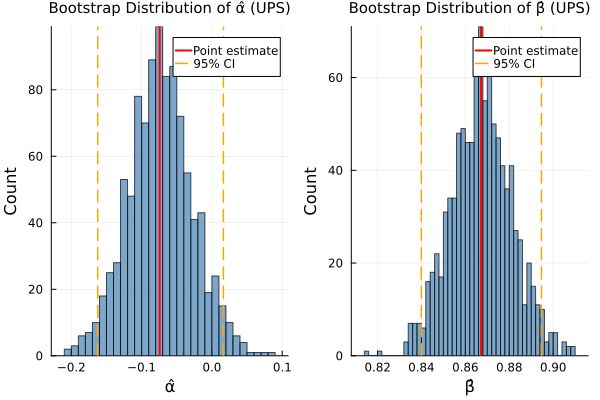

In [7]:
let
    # --- Left panel: bootstrap distribution of α̂ ---
    p1 = histogram(demo_bootstrap["alpha_samples"], bins=50, alpha=0.7, color=:steelblue,
        xlabel="α̂", ylabel="Count", title="Bootstrap Distribution of α̂ ($(demo_ticker))", label="", titlefontsize=10);
    vline!(p1, [est.α], lw=2, color=:red, label="Point estimate");
    vline!(p1, [demo_bootstrap["alpha_ci_95"]...], lw=1.5, ls=:dash, color=:orange, label="95% CI");

    # --- Right panel: bootstrap distribution of β̂ ---
    p2 = histogram(demo_bootstrap["beta_samples"], bins=50, alpha=0.7, color=:steelblue,
        xlabel="β̂", ylabel="Count", title="Bootstrap Distribution of β̂ ($(demo_ticker))", label="", titlefontsize=10);
    vline!(p2, [est.β], lw=2, color=:red, label="Point estimate");
    vline!(p2, [demo_bootstrap["beta_ci_95"]...], lw=1.5, ls=:dash, color=:orange, label="95% CI");

    # --- Combine panels ---
    plot(p1, p2, layout=(1,2), size=(600, 400), legend=:topright)
end

___
## Task 3: Estimate SIM Parameters for All Tickers and Save
In this task, we scale the estimator from a single ticker to the full 424-ticker universe and save the results for downstream notebooks.

Having validated the estimator on a single ticker, we now scale to the full 424-ticker universe. The downstream min-variance and Sharpe-ratio notebooks need $(\alpha_{i}, \beta_{i}, \sigma_{\varepsilon,i})$ for every asset to assemble the SIM covariance matrix, so batch estimation is not optional: it is the entire point.

> __What are we going to do?__
>
> We loop over all 424 tickers, calling [the `estimate_sim(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.estimate_sim) and [the `bootstrap_sim(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.bootstrap_sim) for each. The results are saved to a [JLD2](https://github.com/JuliaIO/JLD2.jl) file that downstream sessions (Sessions 2-4) can load directly.

The code below estimates SIM parameters and bootstrap distributions for all tickers and stores them in `sim_estimates::Vector{MySIMParameterEstimate}` and `bootstrap_results::Dict{String,Dict{String,Any}}` for downstream use.

In [8]:
sim_estimates, bootstrap_results = let

    # --- Step 1: Allocate storage ---
    estimates = MySIMParameterEstimate[];
    bootstraps = Dict{String, Dict{String,Any}}();

    # --- Step 2: Loop over all tickers ---
    for (i, ticker) ∈ enumerate(all_tickers)

        # compute daily log growth rates for this ticker
        prices = dataset[ticker][:, :close];
        returns = [(1.0/Δt) * log(prices[t]/prices[t-1]) for t ∈ 2:length(prices)];

        # estimate SIM parameters
        est = estimate_sim(market_returns, returns, ticker; δ=0.0);
        push!(estimates, est);

        # bootstrap uncertainty quantification
        bs = bootstrap_sim(market_returns, returns, ticker;
            δ=0.0, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED);
        bootstraps[ticker] = bs;

        # progress update every 100 tickers
        if i % 100 == 0
            println("  Processed $(i)/$(length(all_tickers)) tickers...")
        end
    end

    println("Completed SIM estimation for $(length(estimates)) tickers")

    estimates, bootstraps
end;

  Processed 100/424 tickers...
  Processed 200/424 tickers...
  Processed 300/424 tickers...
  Processed 400/424 tickers...
Completed SIM estimation for 424 tickers


The two tails of the $R^{2}$ distribution tell us where SIM works and where it does not.

* __High-$R^{2}$ end:__ Expect tickers whose fundamentals are directly tied to broad market conditions: financials, diversified industrials, and large-cap index ETFs. A single market factor captures most of their variance.
* __Low-$R^{2}$ end:__ Expect commodity ETFs, precious metals, energy trackers, and consumer staples, where each asset has its own supply-demand dynamics that the equity market factor does not explain.
* __What this means for SIM:__ The dispersion across those two groups is exactly what the factor model is designed to isolate, assigning the market-explained part to $\beta_i \sigma_m$ and the rest to $\sigma_{\varepsilon,i}$.

The two 10-ticker tables below confirm this pattern on the synthetic training universe.

In [9]:
let
    # --- Step 1: Build summary DataFrame ---
    # α and σ_ε are in annualized growth-rate units (1/year). We display both
    # the growth-rate convention (·100) and the finance convention
    # (σ_ε / sqrt(252) · 100) side by side so practitioners can read either.
    summary_df = DataFrame(
        "Ticker" => [e.ticker for e ∈ sim_estimates],
        "α (%/yr)" => [round(e.α * 100, digits=2) for e ∈ sim_estimates],
        "β" => [round(e.β, digits=3) for e ∈ sim_estimates],
        "σ_ε grow (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ sim_estimates],
        "σ_ε vol (%/yr)" => [round(e.σ_ε / sqrt(252) * 100, digits=2) for e ∈ sim_estimates],
        "R²" => [round(e.r², digits=3) for e ∈ sim_estimates],
        "β CI" => [let bs = bootstrap_results[e.ticker]; ci = bs["beta_ci_95"];
            "[$(round(ci[1], digits=3)), $(round(ci[2], digits=3))]" end for e ∈ sim_estimates]
    );

    # --- Step 2: Sort by R² ---
    sort!(summary_df, :R², rev=true);

    # --- Step 3: Display top 10 ---
    println("Top 10 tickers by R² (strongest market-factor exposure):")
    pretty_table(first(summary_df, 10); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 4: Display bottom 10 ---
    println("\nBottom 10 tickers by R² (most idiosyncratic):")
    pretty_table(last(summary_df, 10); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

Top 10 tickers by R² (strongest market-factor exposure):
 -------- ---------- --------- ----------------- ---------------- --------- ----------------
  Ticker   α (%/yr)         β   σ_ε grow (%/yr)   σ_ε vol (%/yr)        R²             β CI 
  String    Float64   Float64           Float64          Float64   Float64           String 
 -------- ---------- --------- ----------------- ---------------- --------- ----------------
     SPY        0.0       1.0               0.0              0.0       1.0       [1.0, 1.0]
     BLK      -3.93     1.326             138.0              8.7       0.9   [1.314, 1.338]
     ETN      -0.64     1.271             132.3             8.34       0.9   [1.259, 1.282]
      MS      -2.94     1.466             153.4             9.67     0.899    [1.453, 1.48]
    TROW     -11.69     1.365             146.4             9.23     0.894   [1.352, 1.377]
     AMP      -2.59     1.566             184.6            11.63     0.875    [1.55, 1.583]
     TEL      -4.76

Save the complete SIM estimation results to disk for use in downstream sessions. The saved file contains the parameter estimates, full bootstrap distributions, and market volatility.

This parameter file is the input to every downstream Session 1 notebook. The min-variance and Sharpe-ratio optimizers both consume $(\alpha_{i}, \beta_{i}, \sigma_{\varepsilon,i})$ to assemble the SIM covariance matrix, given by:

$$\Sigma_{ij} = \beta_{i}\beta_{j}\sigma_{m}^{2} + \delta_{ij}\sigma_{\varepsilon,i}^{2}$$

which is the key ingredient that makes Markowitz optimization tractable on a 400+ ticker universe. Without this reduction, the optimizer would need to estimate $N(N+1)/2 \approx 90{,}000$ free parameters from a limited history; with SIM it needs only $N + 1 \approx 425$.

The code below saves the results using [the `save_results(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.save_results).

In [10]:
let

    # --- Step 1: Compute market volatility (needed for build_sim_covariance downstream) ---
    # σ_m is the sample std of annualized market growth rates (units: 1/year).
    σ_m = std(market_returns);

    # --- Step 2: Save to JLD2 ---
    # Includes both MySIMParameterEstimate objects (for covariance construction)
    # and flat vectors in the calibration-dict format (for generate_hybrid_scenario).
    save_path = joinpath(_PATH_TO_DATA, "sim-parameter-estimates.jld2");
    save_results(save_path, Dict(
        "sim_estimates"     => sim_estimates,
        "bootstrap_results" => bootstrap_results,
        "tickers"           => all_tickers,
        "n_tickers"         => length(all_tickers),
        "alpha"             => [est.α for est ∈ sim_estimates],
        "beta"              => [est.β for est ∈ sim_estimates],
        "sigma_eps"         => [est.σ_ε for est ∈ sim_estimates],
        "r_squared"         => [est.r² for est ∈ sim_estimates],
        "sigma_market"      => σ_m,
    ));

    println("Saved SIM parameter estimates to: $(save_path)")
    println("  $(length(sim_estimates)) ticker estimates")
    println("  $(length(bootstrap_results)) bootstrap distributions (1,000 replicates each)")
    println("  Market σ_m (growth rate %/yr):  $(round(σ_m * 100, digits=1))%")
    println("  Market finance vol (%/yr):      $(round(σ_m / sqrt(252) * 100, digits=2))%")
end;

Saved SIM parameter estimates to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/sim-parameter-estimates.jld2
  424 ticker estimates
  424 bootstrap distributions (1,000 replicates each)
  Market σ_m (growth rate %/yr):  312.3%
  Market finance vol (%/yr):      19.68%


___
## Summary
This example demonstrated SIM parameter estimation for a single asset, bootstrap uncertainty quantification, and batch estimation across the full 424-ticker synthetic training universe.

> __Key Takeaways:__
>
> * __SIM decomposes each asset into market and firm-specific components:__ Regularized OLS produces $(\alpha, \beta, \sigma_{\varepsilon})$ and an $R^{2}$ that together quantify how much of a ticker's behavior is market-factor exposure versus idiosyncratic risk. We can rerun the single-ticker sections of this notebook on any asset in the universe by changing the `demo_ticker` variable.
> * __Bootstrap confirms estimator reliability:__ Residual resampling produces empirical standard errors and confidence intervals for $\alpha$ and $\beta$ without parametric assumptions beyond the fitted SIM. A bootstrap-to-theoretical SE ratio near 1 validates the Gaussian error model, and tight CIs that clearly exclude zero mean the downstream portfolio optimizer can trust the parameters.
> * __Batch estimation feeds the SIM covariance matrix:__ Running the estimator across all 424 tickers produces the complete parameter set $(\alpha_{i}, \beta_{i}, \sigma_{\varepsilon,i})$ for every asset. The min-variance and Sharpe-ratio notebooks consume this file to assemble $\Sigma_{ij} = \beta_{i}\beta_{j}\sigma_{m}^{2} + \delta_{ij}\sigma_{\varepsilon,i}^{2}$, the covariance structure that makes Markowitz optimization tractable on a 400+ ticker universe.

The saved parameter file is consumed by both Core Build examples ([min-variance](eCornell-AI-Finance-S1-Example-Core-BuildMinVariancePortfolio-RA-May-2026.ipynb) and [tangent / max-Sharpe](eCornell-AI-Finance-S1-Example-Core-MinVariancePortfolio-RRFA-May-2026.ipynb)) and by Sessions 2-4 for preference weight computation and covariance construction.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.